##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** Need Help

**Student names & numbers:**
* [Xue Hu] - [100193]
* [Roos Hogervorst] - [101484]
* [Sas van Damme] - [101990]


---

## 0. Iteration setup

**Import libraries**

In [1007]:
# CODE CELL: import the necessary libraries for this iteration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load and merge datasets**

In [1008]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df_inventory = pd.read_csv("./data/ships_inventory_clean.csv")
df_inspections = pd.read_csv("./data/ship_inspections_iter2.csv")


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

The current problem is that the data, is fragmented data. For example, we have sales records in one file and technical inspection logs in another. This is a risk for a multitude of reasons. First of all, it is incomplete information. Important columns like Propulsion_Type and Reactor_Power have missing values, in this case ~29,000 missing reactor readings. If we ignore this, then we might sell a high-tech antimatter ship for the price of a basic ion drive vessel simply because the data was not filled. 

Secondly, it is a safety liability. There are overclocked reactors in the data (outliers up to 360 TW). Without a system to flag these, we risk selling illegal, unstable ships that could lead to some nasty business. Like having a lawsuit filed against us.

Lastly, our sales team are analysts, not engineers. They cannot look at a raw number like 75 TW and know if the ship is safe. A lack of unified rating (Pristine/Operational/Critical) means every salesperson uses their own gut feeling to judge a ship's condition, which leads back to the inconsistent pricing crisis from iteration 1. 

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

The current business objective is to act as a bridge between engineering and sale by creating a unified safety & quality rating system. So, a standardized, rule-based expert system removes the variability of human judgment. By setting rules based on ship age (Model_Cycle), price (Galactic_Credits), and engine stats, we can ensure that every ship is categorized using the same safety threshold. 

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

In iteration 1, we were doing regression (predicting a continuous price). Now, we are assigning ships to specific categories: pristine, operational, or critical. It is supervised because we have the Hull_Integrity column from the mechanics, which serves as our ground truth to check if our rules actually work. 

**Success criteria**

*Determine success criteria for this iteration*

To determine if our model is better than gut feeling, we have set 3 specific targets. 
1. Data Integrity: All the ships from the cleaned iteration 1 inventory must be successfully merged with their inspection logs. 
2. Model Accuracy: Our manual classification model must achieve an overall accuracy of at least 75% compared to the mechanics' notes. 
3. Safety Benchmark (Critical Recall): One of our biggest risks is selling a dangerous ship, so we aim for a recall of >80% for critical ships. It is better to label a safe ship as critical accidentally than to label a critical ship as operational. Because for us, it is one missing sale against the chance of a disaster happening. 

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [1009]:
# CODE CELL: Show basic statistics and information
df_inspections.info()
df_inspections.describe()

<class 'pandas.DataFrame'>
RangeIndex: 368315 entries, 0 to 368314
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Ship_ID          368315 non-null  int64  
 1   Hull_Integrity   368315 non-null  str    
 2   Reactor_Power    338877 non-null  float64
 3   Propulsion_Type  311705 non-null  str    
 4   Ship_Class       368315 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 14.1 MB


,Ship_ID,Reactor_Power
count,3.683150e+05,338877.000000
mean,7.311484e+09,71.592584
std,4.381188e+06,44.644084
min,7.301583e+09,30.000000
25%,7.308103e+09,40.000000
50%,7.312604e+09,60.000000
75%,7.315244e+09,80.000000
max,7.317101e+09,360.000000


categorical: Hull_Integrity, Propulsion_Type, and Ship_Class

numerical: Reactor_Power

**Findings:**
1. Reactor Power Distribution:
Reactor_Power ranges from 30 to 360 TW, with an average value of about 71.6 TW. Most ships fall between 40 and 80 TW, suggesting that the majority of ships operate within a moderate power range, while a small number of ships have very high reactor power.

2. Missing Values:
Reactor_Power has 338,877 non-null values, meaning about 29,438 values are missing. Propulsion_Type also contains missing values, which will need to be handled during the data preparation stage.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

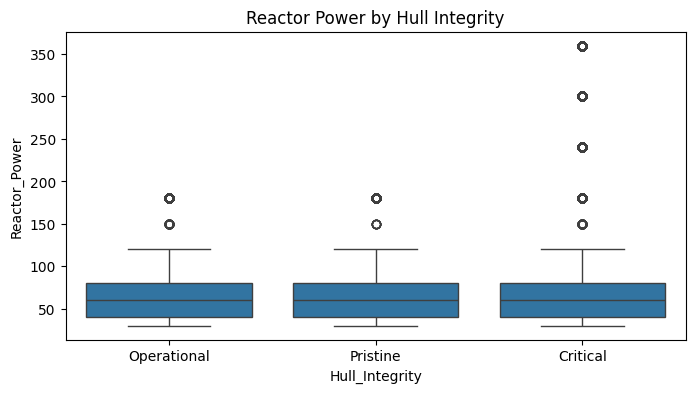

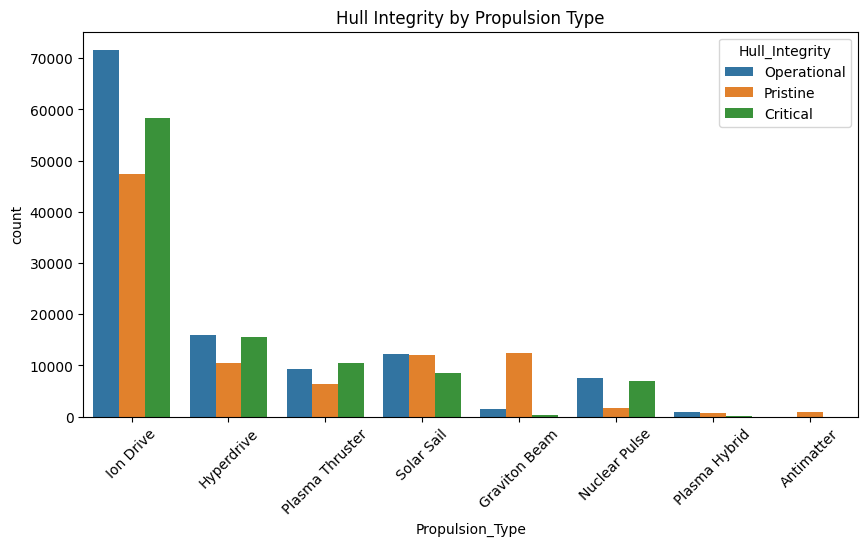

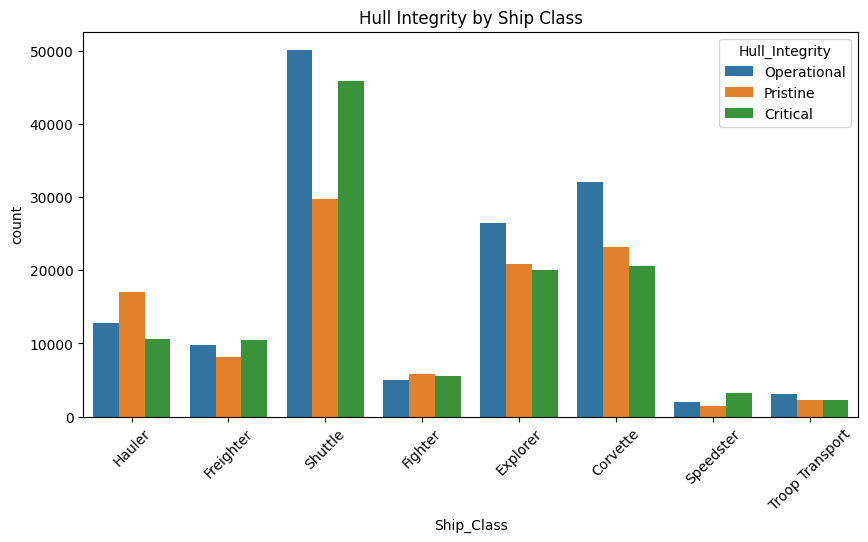

In [1010]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)

# Reactor Power vs Hull Integrity
plt.figure(figsize=(8,4))
sns.boxplot(x='Hull_Integrity', y='Reactor_Power', data=df_inspections)
plt.title("Reactor Power by Hull Integrity")
plt.show()


# Propulsion Type vs Hull Integrity
plt.figure(figsize=(10,5))
sns.countplot(data=df_inspections, x='Propulsion_Type', hue='Hull_Integrity')
plt.title("Hull Integrity by Propulsion Type")
plt.xticks(rotation=45)
plt.show()


# Ship Class vs Hull Integrity
plt.figure(figsize=(10,5))
sns.countplot(data=df_inspections, x='Ship_Class', hue='Hull_Integrity')
plt.title("Hull Integrity by Ship Class")
plt.xticks(rotation=45)
plt.show()


**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

**Data insights:**
1. Reactor Power and Ship Condition

    Most ships have Reactor_Power between 40 and 80 TW. However, some ships have extremely high values (above ~150 TW), which may indicate abnormal or unsafe reactors.

2. Propulsion Type

    Most ships use Ion Drive propulsion, making it the most common technology in the fleet. Some propulsion types, such as Graviton Beam, appear to have a relatively higher proportion of Pristine ships.

3. Ship Class

    Different ship classes contain ships in all three condition categories, and no single class clearly determines ship condition. This suggests that ship class alone may not be a strong indicator of hull integrity.

**Quality issues:**
1. Missing values

    The dataset contains missing values in two important columns. Reactor_Power has 338,877 non-null values, meaning about 29,438 values are missing. Propulsion_Type also contains missing entries, which will need to be addressed during data preparation.

2. Outliers

    The Reactor_Power variable contains unusually high values, reaching up to 360 TW, which are far above the typical range. These extreme values may represent abnormal or modified reactors and should be handled during data preparation.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

Propulsion_Type
Ion Drive          172918
Hyperdrive          40431
Solar Sail          32085
Plasma Thruster     25574
Nuclear Pulse       14803
Graviton Beam       13983
Plasma Hybrid        1746
Antimatter            814
Name: count, dtype: int64
Hull_Integrity
Operational    137801
Critical       115408
Pristine       104108
Name: count, dtype: int64


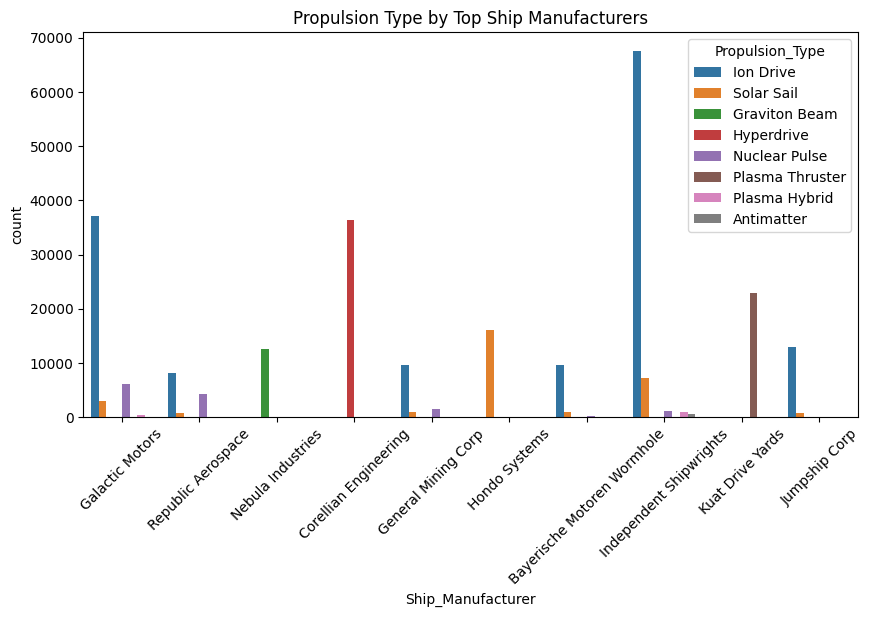

<class 'pandas.DataFrame'>
Index: 355071 entries, 0 to 357316
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            355071 non-null  int64  
 1   Galactic_Credits   355071 non-null  int64  
 2   Model_Cycle        355071 non-null  float64
 3   Ship_Manufacturer  355071 non-null  str    
 4   Sector             355071 non-null  str    
 5   Hull_Integrity     355071 non-null  str    
 6   Reactor_Power      355071 non-null  float64
 7   Propulsion_Type    355071 non-null  str    
 8   Ship_Class         355071 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 27.1 MB


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.550710e+05,355071.000000,355071.000000,355071.000000
mean,7.311481e+09,18676.428799,7511.248353,68.929651
std,4.382615e+06,13250.473090,8.956381,38.278429
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308096e+09,7900.000000,7508.000000,40.000000
50%,7.312595e+09,15800.000000,7513.000000,60.000000
75%,7.315242e+09,27500.000000,7517.000000,80.000000
max,7.317101e+09,68788.000000,7522.000000,240.000000


In [1011]:
# CODE CELL: Data cleaning, preprocessing
df = df_inventory.merge(df_inspections, on="Ship_ID", how="left")

# check duplicates
df.duplicated().sum()

# check possible typos in categorical columns
print(df["Propulsion_Type"].value_counts())
print(df["Hull_Integrity"].value_counts())

# Analyze the distribution of propulsion types across different manufacturers
top_manufacturers = df["Ship_Manufacturer"].value_counts().head(10).index
df_top = df[df["Ship_Manufacturer"].isin(top_manufacturers)]
plt.figure(figsize=(10,5))
sns.countplot(data=df_top, x="Ship_Manufacturer", hue="Propulsion_Type")
plt.xticks(rotation=45)
plt.title("Propulsion Type by Top Ship Manufacturers")
plt.show()

# fill missing values in Propulsion_Type with the most common type for that manufacturer
df["Propulsion_Type"] = df["Propulsion_Type"].fillna(df.groupby("Ship_Manufacturer")["Propulsion_Type"].transform(lambda x: x.mode()[0]))

df["Reactor_Power"] = df["Reactor_Power"].fillna(df["Reactor_Power"].median())

# remove ships with reactor power above the 99th percentile
upper_limit = df["Reactor_Power"].quantile(0.99)
df = df[df["Reactor_Power"] <= upper_limit]


df.info()
df.describe()


Explanation:
1. The inventory and inspection datasets were merged using Ship_ID with a left join. A left join was used to ensure that all ships in the inventory are retained

2. Missing values in Propulsion_Type were filled using the most common propulsion type for each Ship_Manufacturer. Countplot showed that manufacturers tend to specialize in specific propulsion technologies.

3. Missing values in Reactor_Power were filled using the median. Because the reactor power distribution contains extreme values, and the median is less affected by outliers.

4. Reactor power values above the 99th percentile were removed. These extreme values are far outside the normal range and may represent abnormal or overclocked reactors, which could influence the analysis if keep in the dataset.

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [1012]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [1013]:
# CODE CELL: Model training and setup code
def classification_model(row):
    # Critical
    if row["Model_Cycle"] < 7510:
        return "Critical"

    if row["Galactic_Credits"] < 8000 and row["Reactor_Power"] > 70:
        return "Critical"

    # Pristine
    if row["Propulsion_Type"] == "Graviton Beam":
        return "Pristine"
    
    if row["Galactic_Credits"] > 20000 and row["Model_Cycle"] >= 7514:
        return "Pristine"

    if row["Galactic_Credits"] > 45000 and row["Reactor_Power"] < 90:
        return "Pristine"

    return "Operational"

df["Predicted_Hull_Integrity"] = df.apply(classification_model, axis=1)


**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

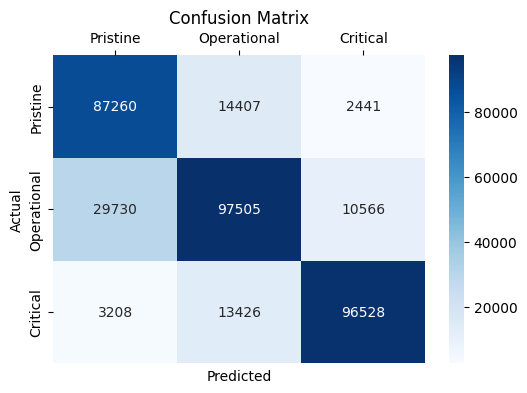

              precision    recall  f1-score   support

    Pristine       0.73      0.84      0.78    104108
 Operational       0.78      0.71      0.74    137801
    Critical       0.88      0.85      0.87    113162

    accuracy                           0.79    355071
   macro avg       0.80      0.80      0.80    355071
weighted avg       0.80      0.79      0.79    355071



In [1014]:
# CODE CELL: Model evaluation code

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["Pristine","Operational","Critical"]

cm = confusion_matrix(
    df["Hull_Integrity"],
    df["Predicted_Hull_Integrity"],
    labels=labels
)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.gca().xaxis.tick_top()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


print(classification_report(
    df["Hull_Integrity"],
    df["Predicted_Hull_Integrity"],
    labels=labels
))


**Explanation:**
Ships with Model_Cycle earlier than 7510 are labeled Critical because older ships are more likely to have structural problems. Ships with very low value (<8000 credits) but relatively high reactor power (>70 TW) are also classified as Critical, as this combination indicate unsafe. Ships using Graviton Beam propulsion are labeled Pristine because earlier analysis showed a higher proportion of pristine ships with this technology. Ships that are new and valuable (Galactic_Credits > 20000 and Model_Cycle ≥ 7514) or very expensive (>45000 credits) with normal reactor power are also classified as Pristine. All remaining ships are labeled Operational.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xue | *Handled missing values and removed extreme outliers. Implemented the rule-based classification model and evaluated the model with a confusion matrix and classification metrics.* | *I learned how to merge datasets using a key column and how to handle missing values differently for categorical and numerical variables. I also learned how to improve a model by adjusting classification rules and thresholds. By testing different rules and analyzing precision, recall, and the confusion matrix, I learned how to refine the model to make the predictions more accurate.* |
| Sas | *Described the problem surrounding the safety inspections, justified why a standardized, rule-based expert system is needed, and determined success criteria for this iteration.* | *I learned that in classification tasks, overall accuracy isn't always the most important number. For nebula brokerage, the business risk of a  false negative (labeling a critical ship as safe) is much higher than mislabeling a pristine ship. This taught me to set success criteria based on recall for critical ships, rather than just solely aiming for a high accuracy percentage.* |
| Student name 3 | *Contribution description* | *Personal lessons learned this iteration* |